# Overview:
This notebook will assess the retail trends, patterns and insights of the selected dataset to better understand customer wants, needs and shopping tendencies to, as a result, help marketing and inform planning decisions.


In [23]:
import pandas as pd
import numpy as np

In [24]:
db = pd.read_csv('retail_sales_dataset.csv')
db_copy = db.copy()
db_copy.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [25]:
db_copy.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [26]:
db_copy.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [27]:
#Converting Date to DateTime Format for easier usage:
db_copy['Date'] = pd.to_datetime(db_copy['Date'])

#Converting string columns into teh correct dataset
db_copy[['Gender', 'Transaction ID', 'Product Category']] = db_copy[['Gender', 'Transaction ID', 'Product Category']].astype('string')

#Converting category data columns into the appropriate dataset:
db_copy['Gender'] = db_copy['Gender'].astype('category')
db_copy['Product Category'] = db_copy['Product Category'].astype('category')

print(db_copy.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   string        
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   category      
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   category      
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: category(2), datetime64[ns](1), int64(4), object(1), string(1)
memory usage: 57.0+ KB
None


In [28]:
db_copy.isna().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

Dataset was actaully uploaded generally clean and contains no NA or NULL values, hence no correction adjustments needed here. Moved on to Data Validation and Analysis Preperations:

In [29]:
print(db_copy.shape)


(1000, 9)


In [30]:
#I also decided to rename the Total Amount column just so that it didn't become confusing when I started adding new int columns later that do calculations!
db_copy.rename(columns={"Total Amount": "Total Sale Price"}, inplace=True)
print(db_copy.columns.tolist())


['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Sale Price']


## Dataset Structural Validation Check Breakdown:
Can confirm that the dataset still has 1000 elements and 9 columns as it did when imported, meaning no elements or data has gone missing.

All columns are as expected and have been renamed accordingly if felt needed.

No missing element values were detected or observed. 

Quick top and tail visual checks confirm that all values seem to look reasonable and ready for usage.

In [31]:
# Check each row to see if it has any duplicates in the dataset:
duplicate_rows = db_copy.duplicated().sum()
print("N0. of duplicate rows:", duplicate_rows)

# Check each transaction ID is unique:
duplicate_ID = db_copy.duplicated("Transaction ID").sum()
print("N0. of duplicate ID's:", duplicate_ID)

# Quick check to make sure all unique elements = nuumber of total elements
print(db_copy["Transaction ID"].nunique())
print(len(db_copy))

N0. of duplicate rows: 0
N0. of duplicate ID's: 0
1000
1000


## Data Duplicates and Integrity Checks:


x No fully duplicated rows and hence no actions needed

x All transaction ID's are unique and hence all transactions individual 

x Number check confirms that all elements of the dataframe and unique and equal to number of rows.


In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

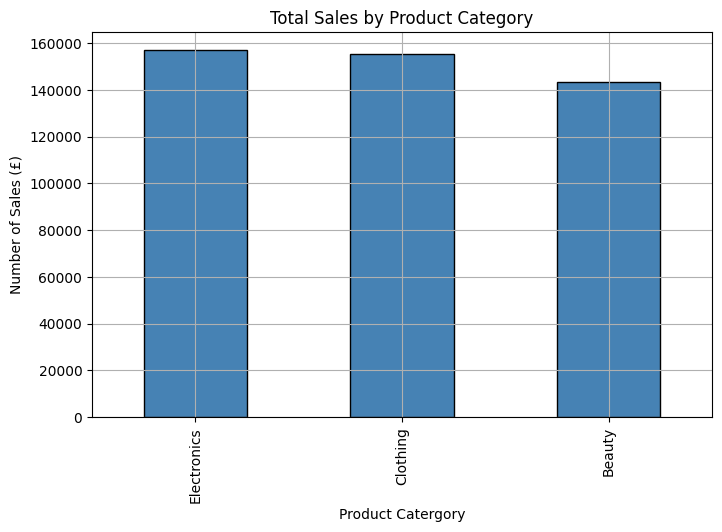

In [33]:
category_sales = db_copy.groupby('Product Category')['Total Sale Price'].sum().sort_values(ascending=False)
plt.figure(figsize=(8,5))
category_sales.plot(kind='bar',color='steelblue', edgecolor='black')

#Finalize Visualization:
plt.title('Total Sales by Product Category')
plt.xlabel('Product Catergory')
plt.ylabel('Number of Sales (£)')
plt.grid()



## Inital Graphing Insights:

On intal observation electronics dominate the market with their overall revenue tally. This suggest there is a stronger customer supply and demand for these compared to beauty and clothing. 

Now this had been observed I will now investigate these trends based on time analysis. 

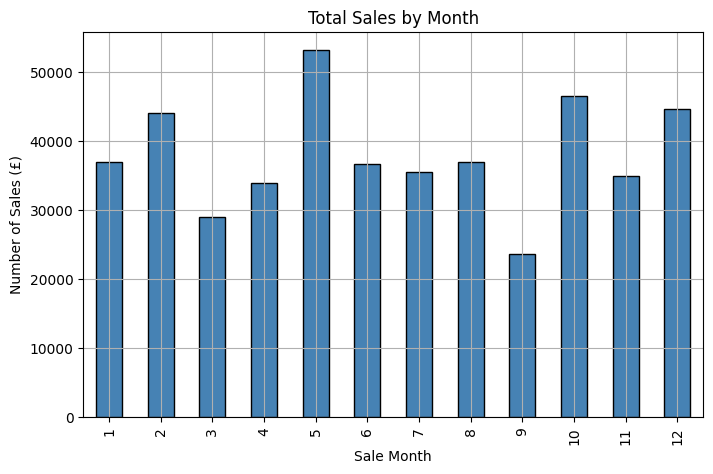

In [34]:
# new column that shows each transaction month
db_copy['Month'] = db_copy['Date'].dt.month


month_sales = db_copy.groupby('Month')['Total Sale Price'].sum().sort_index()
plt.figure(figsize=(8,5))
month_sales.plot(kind='bar',color='steelblue', edgecolor='black')

#Finalize Visualization:
plt.title('Total Sales by Month')
plt.xlabel('Sale Month')
plt.ylabel('Number of Sales (£)')
plt.grid()


 Identified that the most profitable month for revenue is May, followed by October. This trend could be explained by a number of reasonings. Next I will assess the relationship between categories and revenue in the month of may.

In [35]:
db_May = db_copy[db_copy['Month'] == 5]
print(db_May)


#Verify:
print(db_May['Month'].unique()) 


    Transaction ID       Date Customer ID  Gender  Age Product Category  \
3                4 2023-05-21     CUST004    Male   37         Clothing   
4                5 2023-05-06     CUST005    Male   30           Beauty   
30              31 2023-05-23     CUST031    Male   44      Electronics   
36              37 2023-05-23     CUST037  Female   18           Beauty   
47              48 2023-05-16     CUST048    Male   54      Electronics   
..             ...        ...         ...     ...  ...              ...   
973            974 2023-05-03     CUST974    Male   47           Beauty   
984            985 2023-05-30     CUST985  Female   19      Electronics   
987            988 2023-05-28     CUST988  Female   63         Clothing   
989            990 2023-05-25     CUST990  Female   58           Beauty   
995            996 2023-05-16     CUST996    Male   62         Clothing   

     Quantity  Price per Unit  Total Sale Price  Month  
3           1             500             

In [36]:
print(db_May.groupby('Product Category')['Total Sale Price'].sum().sort_values(ascending =False))
month_sales = db_copy.groupby('Month')['Total Sale Price'].sum().sort_values(ascending=False)

print(db_May.groupby('Product Category')['Quantity'].sum().sort_values(ascending =False))
print(db_May['Age'].mean())
print(db_May['Age'].median())


Product Category
Electronics    23245
Clothing       17455
Beauty         12450
Name: Total Sale Price, dtype: int64
Product Category
Clothing       97
Electronics    97
Beauty         65
Name: Quantity, dtype: int64
42.42857142857143
44.0


Peak Category for revenue is Electronics

Peak Category for Quantity Purchased is Clothing and Electronics

Most common age of purchasing around 42-44



IN PROGRESS: Spend by age band:
    
Spend by gender:
    
Average order value by category

In [37]:
#Spend by Age Group:
#Define edges and labels for age group cut
print(db_copy['Age'].describe())
bins=[18,30,40,55,70]
labels= ['Young Adult', 'Adult','Middle Aged', 'Late Middle Aged']

db_copy['Age_band'] = pd.cut(db_copy['Age'], bins=bins, labels=labels, right=False)
print(db_copy.groupby('Age_band')['Quantity'].sum().sort_values(ascending =False))
print(db_copy.groupby('Age_band')['Total Sale Price'].sum().sort_values(ascending =False))
# Age Group purchasing products totalling the most money = 40-55 YO

#Spend by Gender:
print(db_copy.groupby('Gender')['Quantity'].sum().sort_values(ascending =True))
print(db_copy.groupby('Gender')['Total Sale Price'].sum().sort_values(ascending =False))
# Females total the most total revenue and the most quantity in sales


# Want to check the middle aged females vs males
gender_ages = db_copy.groupby(['Age_band','Gender'])['Total Sale Price'].sum()
print(gender_ages)

av_order_price = db_copy.groupby(['Age_band','Gender'])['Total Sale Price'].mean()
print(av_order_price)

av_order_quanitity = db_copy.groupby(['Age_band','Gender'])['Quantity'].sum()
print(av_order_quanitity)

order_total_units = db_copy.groupby(['Age_band','Gender'])['Transaction ID'].count()
print(order_total_units)

count    1000.00000
mean       41.39200
std        13.68143
min        18.00000
25%        29.00000
50%        42.00000
75%        53.00000
max        64.00000
Name: Age, dtype: float64
Age_band
Middle Aged         865
Young Adult         625
Late Middle Aged    515
Adult               509
Name: Quantity, dtype: int64
Age_band
Middle Aged         146330
Young Adult         123155
Adult                96325
Late Middle Aged     90190
Name: Total Sale Price, dtype: int64
Gender
Male      1216
Female    1298
Name: Quantity, dtype: int64
Gender
Female    232840
Male      223160
Name: Total Sale Price, dtype: int64
Age_band          Gender
Young Adult       Female    63525
                  Male      59630
Adult             Female    49245
                  Male      47080
Middle Aged       Female    74790
                  Male      71540
Late Middle Aged  Female    45280
                  Male      44910
Name: Total Sale Price, dtype: int64
Age_band          Gender
Young Adult       Femal

## Findings based on age and gender statistics

### General:
It is observed that the age group totalling the highest overall revenue are those of the 40-54 year old bracket. Not only do they mass the most revenue, they generated £146,330 in total revenue, approximately £23,000 more than Young Adults at £123,155 but middle aged customers also led in total purchased and total transcations.

Gender was also analysed and identified as a pattern, females dominated in the revenue and quanitity of purchases and hence encouraged a deeper analysis into the gender trends of those in the middle age bracket.

### Average Insights:
Generally can observe that the younger age groups see women dominating the average sale price, with adults having the biggest difference. Middle aged and late middle aged consumers tended to be dominated by men when investigating the average sale price. 

### Quantity Inisights:
Throughout all age ranges the quantity averages are either dominated by females or other than adults where both genders were borderline equal. This informs that women also dominate the purchase quantities.

### Total Transaction Inisghts:
finally i assessed total transaction based on gender and age groups. based on this data i identified women once again take most dominace. This informs me that retail marketing should generally dominate towards addressing women although the gaps tend to not be massive as they tend to spend less per trip but seem to tally more revenue overall.


In [38]:
# Deeper investigation into MAY OUTLINER:

#average month revenue compared to each month but specifcially may
month_sales = db_copy.groupby('Month')['Total Sale Price'].sum()
print(month_sales.mean())
print(month_sales[5])

#may is clearly higher than average, by currency of 15150, now check against other months using standard deviation:
print(month_sales.std())



38000.0
53150
8030.20349566673


## May anomaly deeper investigation:

I decided to delve deeper into the trend identified in May's total sales before I continued further.
I began by checking May’s total revenue in comparison to the average of the monthly revenue across all of the months. This was identified as an increase over the average of 15,150, with the average total revenue being 38,000 and May’s being 53,150.
 I then decided to check the standard deviation of all months, which worked out as 8,030. This was a standard deviation of 1.9x compared to May’s total sales. To confirm this outlier with certainty, I would need more data from multiple years to check this deviation and compare it to the dataset for this year.


In [39]:
#normalising age and total sale price columns in preperation for k-means clustering:

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
cluster_data = db_copy[['Age', 'Total Sale Price']]
cluster_data_scaled = scaler.fit_transform(cluster_data)

print(cluster_data_scaled[:5])

[[-0.54056476 -0.5467043 ]
 [-1.12559156  0.97191876]
 [ 0.62948884 -0.76109815]
 [-0.32117971  0.07861108]
 [-0.83307816 -0.63603507]]


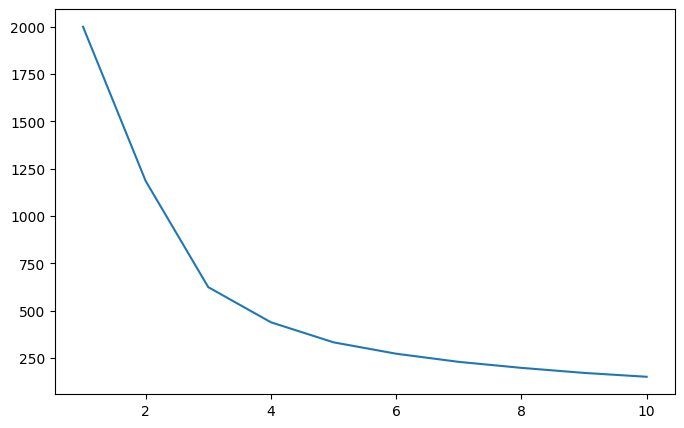

In [40]:
from sklearn.cluster import KMeans

#elbow method for the best kmeans cluster number:

elbow_meth_list = []
for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(cluster_data_scaled)
    
    elbow_meth_list.append(kmeans.inertia_)
    
    
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), elbow_meth_list)



Elbow appears to be between 3/4 suggesting that 3 is the optimal number for clusters.

kmeans = KMeans(n_clusters = 3, random_state =42)
kmeans.fit(cluster_data_scaled)


In [43]:
cluster_colours = ['#FF69B4', '#FFB6C1', '#DDA0DD']


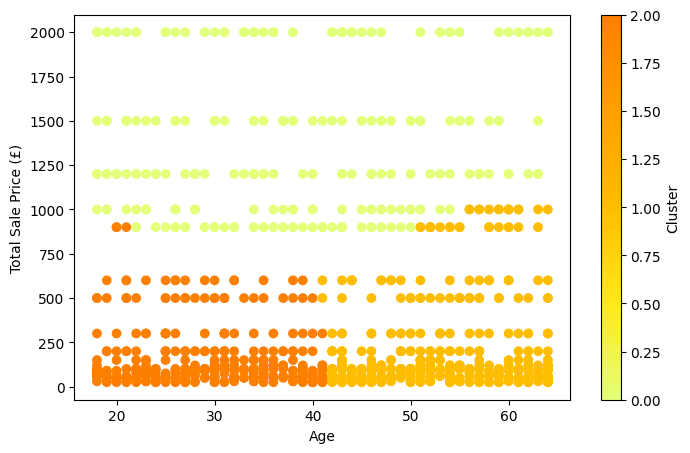

In [42]:
kmeans = KMeans(n_clusters = 3, random_state =42)
kmeans.fit(cluster_data_scaled)


plt.figure(figsize=(8,5))
plt.scatter(db_copy['Age'], db_copy['Total Sale Price'], c=kmeans.labels_, cmap='Wistia')

plt.xlabel('Age')
plt.ylabel('Total Sale Price (£)')
plt.colorbar(label='Cluster')
plt.show()


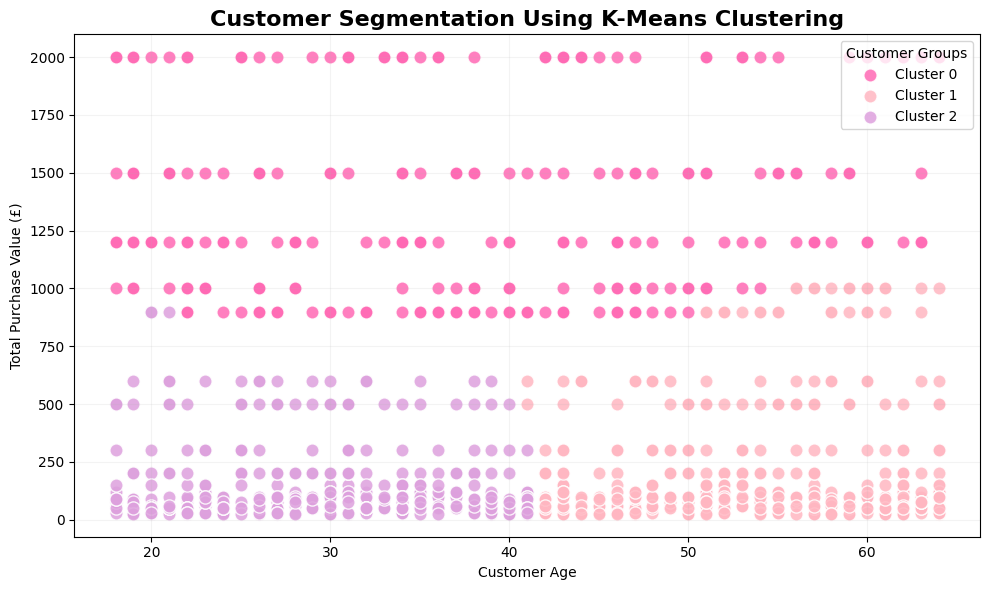

In [44]:

plt.figure(figsize=(10,6))

for cluster, colour in enumerate(cluster_colours):
    subset = db_copy[kmeans.labels_ == cluster]
    
    plt.scatter(
        subset['Age'],
        subset['Total Sale Price'],
        color=colour,
        label=f'Cluster {cluster}',
        s=90,
        alpha=0.85,
        edgecolor='white'
    )

plt.title(
    "Customer Segmentation Using K-Means Clustering",
    fontsize=16,
    fontweight='bold'
)

plt.xlabel("Customer Age")
plt.ylabel("Total Purchase Value (£)")

plt.legend(title="Customer Groups")
plt.grid(alpha=0.15)

plt.tight_layout()
plt.show()

Kmeans Scatter split the customers into 3 groups of spenders, low(0-500), mid(500-1000) and high(1000-2000). These spenders are spread pretty evenly across all ages. This was surprising considering information earlier made it seem like middle aged customers spent more in EDA. This could be beacuse kmeans is looking at individual transactions where as my EDA was more transactions rather than assessing each transaction.